<a href="https://colab.research.google.com/github/chloe8407/gpt-2.0-sherlock/blob/main/6_Tiny_GPT_Sherlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toward a Tiny GPT — Sherlock Holmes edition

Karpathy nn-zero-to-hero 흐름의 마지막 단계인 character-level TinyGPT를
**셜록홈즈(The Adventures of Sherlock Holmes, Project Gutenberg #1661)** 텍스트로 학습한다.

추가한 것:
1. 데이터를 tinyshakespeare → 셜록홈즈로 교체 (Gutenberg 헤더/푸터 제거)
2. 생성 함수에 **temperature / top-k** 샘플링 옵션 추가
3. **어텐션 히트맵** 시각화 — 트랜스포머가 어떤 글자에 주목하는지 확인

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# --- 데이터: 셜록홈즈 (Project Gutenberg #1661) ---
URL = "https://www.gutenberg.org/cache/epub/1661/pg1661.txt"
if not Path("sherlock.txt").exists():
    !wget -q -O sherlock.txt {URL}

raw = open("sherlock.txt", "r", encoding="utf-8").read()

# Project Gutenberg 라이선스 헤더/푸터 제거 -> 본문만 학습
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
s = raw.find(start_marker)
e = raw.find(end_marker)
start = raw.find("\n", s) + 1 if s != -1 else 0
end = e if e != -1 else len(raw)
text = raw[start:end].strip()

chars = sorted(list(set(text)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)
data = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)

print("text length:", len(text))
print("vocab_size:", vocab_size)
print("--- sample ---")
print(text[:300])


class NextTokenDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size
    def __len__(self):
        return len(self.data) - self.block_size
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

block_size = 64
dataset = NextTokenDataset(data, block_size)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
xb, yb = next(iter(loader))
print("xb.shape:", xb.shape)

text length: 562202
vocab_size: 88
--- sample ---
The Adventures of Sherlock Holmes

by Arthur Conan Doyle


Contents

   I.     A Scandal in Bohemia
   II.    The Red-Headed League
   III.   A Case of Identity
   IV.    The Boscombe Valley Mystery
   V.     The Five Orange Pips
   VI.    The Man with the Twisted Lip
   VII.   The Adventure of the 
xb.shape: torch.Size([64, 64])


## 모델 정의 (멀티헤드 어텐션 + 어텐션 가중치 저장)

In [2]:
class Head(nn.Module):
    def __init__(self, emb_dim, head_size, block_size, dropout=0.1):
        super().__init__()
        self.key = nn.Linear(emb_dim, head_size, bias=False)
        self.query = nn.Linear(emb_dim, head_size, bias=False)
        self.value = nn.Linear(emb_dim, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.att = None  # 시각화를 위해 마지막 attention weight 저장

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        self.att = wei.detach()          # <-- 어텐션 히트맵용으로 보관
        wei = self.dropout(wei)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, num_heads, block_size, dropout=0.1):
        super().__init__()
        head_size = emb_dim // num_heads
        self.heads = nn.ModuleList([Head(emb_dim, head_size, block_size, dropout) for _ in range(num_heads)])
        self.proj = nn.Linear(emb_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out

In [3]:
class FeedForward(nn.Module):
    def __init__(self, emb_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),
            nn.ReLU(),
            nn.Linear(4 * emb_dim, emb_dim),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, emb_dim, num_heads, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(emb_dim)
        self.sa = MultiHeadAttention(emb_dim, num_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(emb_dim)
        self.ffwd = FeedForward(emb_dim, dropout)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [4]:
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, block_size, emb_dim=128, num_heads=4, num_layers=4, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, emb_dim)
        self.position_embedding = nn.Embedding(block_size, emb_dim)
        self.blocks = nn.Sequential(*[
            Block(emb_dim, num_heads, block_size, dropout) for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(emb_dim)
        self.lm_head = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device)
        tok = self.token_embedding(x)
        pos = self.position_embedding(pos)[None]
        h = tok + pos
        h = self.blocks(h)
        h = self.ln_f(h)
        logits = self.lm_head(h)
        return logits

model = TinyGPT(vocab_size, block_size)
logits = model(xb)
print("logits.shape:", logits.shape)

logits.shape: torch.Size([64, 64, 88])


## 학습


In [5]:
def sequence_cross_entropy(logits, targets):
    return F.cross_entropy(logits.transpose(1, 2), targets)

def train_one_epoch(model, loader, optimizer, device, max_steps=None):
    model.train()
    total_loss, total_count = 0.0, 0
    for step, (xb, yb) in enumerate(loader):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = sequence_cross_entropy(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_count += xb.size(0)
        if max_steps is not None and step + 1 >= max_steps:
            break
    return total_loss / total_count

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
model = TinyGPT(vocab_size, block_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

for epoch in range(50):
    train_loss = train_one_epoch(model, loader, optimizer, device, max_steps=300)
    if epoch % 5 == 0 or epoch == 49:
        print(f"epoch {epoch:2d} | train loss {train_loss:.4f}")

device: cuda
epoch  0 | train loss 2.6428
epoch  5 | train loss 1.7585
epoch 10 | train loss 1.5779
epoch 15 | train loss 1.4832
epoch 20 | train loss 1.4275
epoch 25 | train loss 1.3893
epoch 30 | train loss 1.3600
epoch 35 | train loss 1.3367
epoch 40 | train loss 1.3158
epoch 45 | train loss 1.2996
epoch 49 | train loss 1.2860


## 생성 — temperature & top-k

- **temperature**: 1.0=원본 분포, 낮을수록(0.5) 안정적·반복적, 높을수록(1.3) 다양·산만
- **top-k**: 매 스텝 확률 상위 k개 글자만 후보로 두어 헛소리를 줄임

In [6]:
@torch.no_grad()
def generate(model, block_size, stoi, itos, device,
             start_text="Sherlock Holmes", max_new_tokens=500,
             temperature=1.0, top_k=None):
    model.eval()
    context = torch.zeros((1, block_size), dtype=torch.long, device=device)
    for ch in start_text:
        if ch in stoi:
            ix = torch.tensor([[stoi[ch]]], device=device)
            context = torch.cat([context[:, 1:], ix], dim=1)
    out = list(start_text)
    for _ in range(max_new_tokens):
        logits = model(context)[:, -1, :] / temperature
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits = logits.masked_fill(logits < v[:, [-1]], float("-inf"))
        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1)
        out.append(itos[ix.item()])
        context = torch.cat([context[:, 1:], ix], dim=1)
    return "".join(out)


for t in [0.5, 0.8, 1.2]:
    print(f"\n===== temperature={t}, top_k=40 =====")
    print(generate(model, block_size, stoi, itos, device,
                   start_text="Sherlock Holmes", max_new_tokens=400,
                   temperature=t, top_k=40))


===== temperature=0.5, top_k=40 =====
Sherlock Holmes came against to the singular side. I had not seemed to be described that I have
thought a case of the sevent which was standing as the country. It was perhaps the
danger was a long time, and a deal sensation which may be a long bring heart and
so provided that he was made a little record which she had been lost in the street in the matter,
the morning of the great streets of the son of the stable

===== temperature=0.8, top_k=40 =====
Sherlock Holmes seeing at the window which purposes and little remarkable and
search shrough the weave, dreeping in the pense and deadling off his
friends of Larmchaire of the Southam so. But its anything the allar
about the difficty said his askine. I should not be denience. Just how successes communications when I could not
see a little little pointed in a very such in which we peach was
a lady strong and a lo

===== temperature=1.2, top_k=40 =====
Sherlock Holmes came at trains why—I have gives. Sh

## 어텐션 시각화

짧은 문장을 모델에 넣고, 특정 레이어·헤드의 attention weight를 히트맵으로 그린다.
세로축(query)의 각 글자가 가로축(key)의 어떤 이전 글자에 주목하는지를 보여준다.
causal mask 때문에 자기 자신보다 뒤쪽(오른쪽 위 삼각형)은 비어 있다.

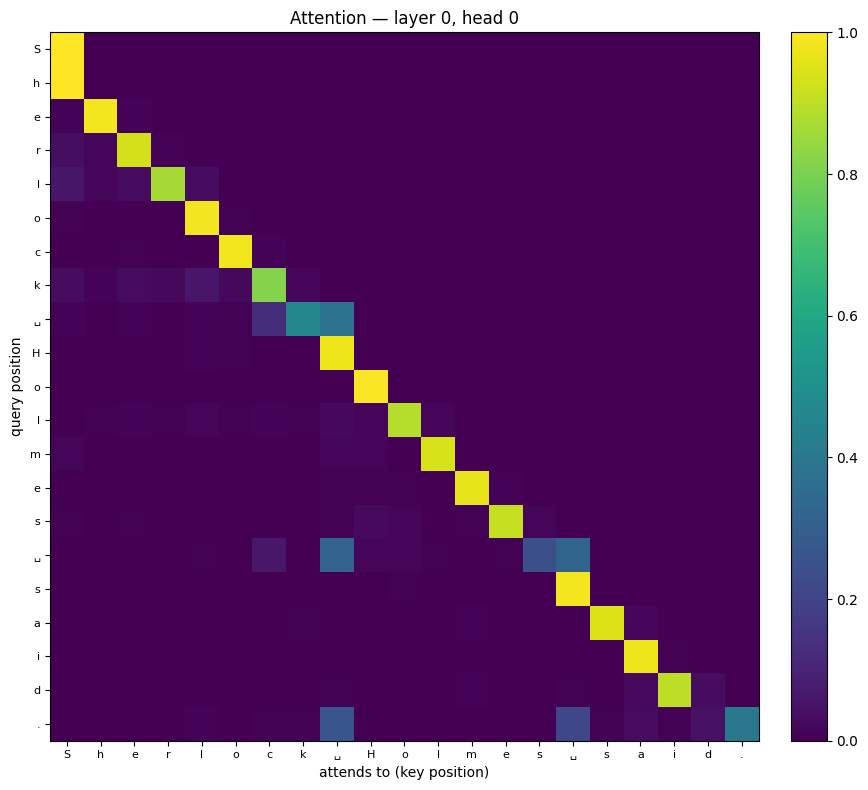

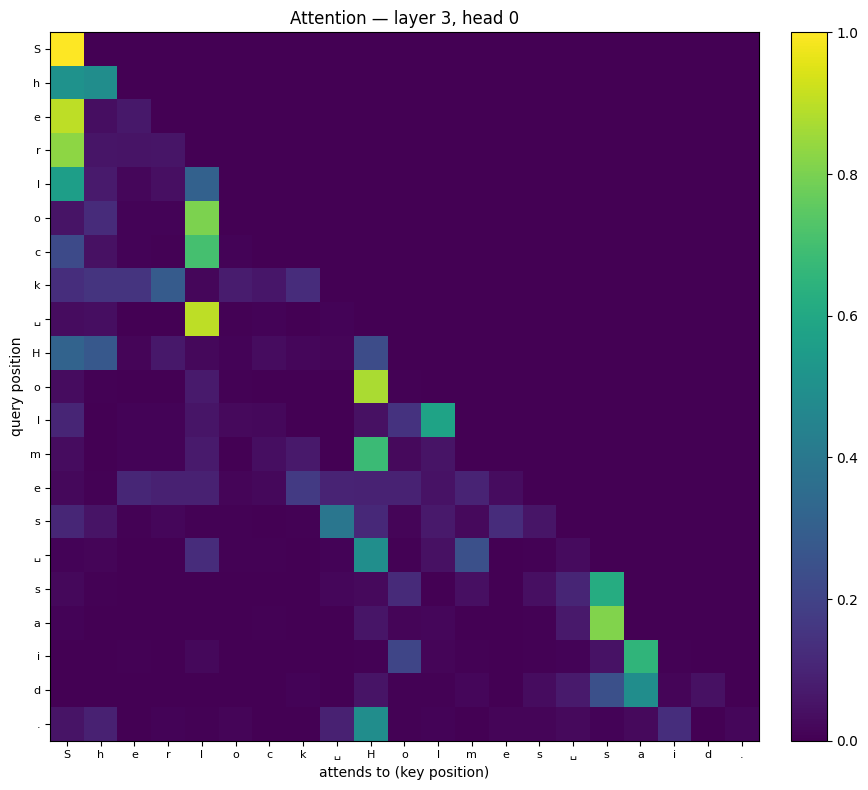

In [8]:
import matplotlib.pyplot as plt

def _lab(c):
    return {" ": "␣", "\n": "⏎", "\t": "→"}.get(c, c)

@torch.no_grad()
def show_attention(model, snippet, stoi, itos, device, layer=0, head=0):
    model.eval()
    idx = [stoi[c] for c in snippet if c in stoi]
    idx = idx[:block_size]                       # block_size 초과 방지
    x = torch.tensor([idx], device=device)
    _ = model(x)                                 # forward로 att 채우기
    att = model.blocks[layer].sa.heads[head].att[0].cpu()  # (T, T)
    toks = [_lab(itos[i]) for i in idx]

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(att, cmap="viridis")
    ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, fontsize=8)
    ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks, fontsize=8)
    ax.set_xlabel("attends to (key position)")
    ax.set_ylabel("query position")
    ax.set_title(f"Attention — layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

show_attention(model, "Sherlock Holmes said.", stoi, itos, device, layer=0, head=0)
show_attention(model, "Sherlock Holmes said.", stoi, itos, device, layer=3, head=0)